# Aula 06 [Hands On Bônus] Detecção de Anomalias em Dados de Transações Financeiras 🕵️‍♂️💳📈🔍

Grupo 7:

Luis Ernani Viniski

Leonardo Barbosa dos Santos

Gabriel Ximenes Bezerra Carrazzoni

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [ ]:
# Carregar os dados
url = "https://raw.githubusercontent.com/devjaynemorais/modelos_descritivos_curso/main/Aula%2005/dados/credit_card.csv"
df = pd.read_csv(url)

In [ ]:
# Remover colunas categóricas e com valores faltantes
df = df.drop(columns=["CUST_ID"])
df = df.dropna()

In [ ]:
# Normalizar os dados
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [ ]:
# Aplicar Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df["IsolationForest_Anomaly"] = iso_forest.fit_predict(df_scaled)

In [ ]:
# Aplicar DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
df["DBSCAN_Anomaly"] = dbscan.fit_predict(df_scaled)

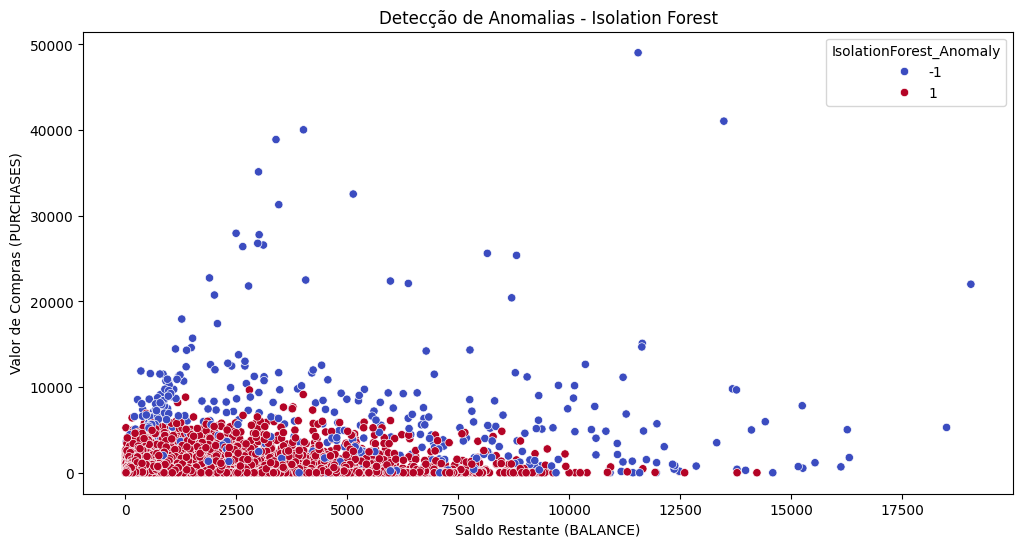

In [ ]:
# Visualizar os resultados do Isolation Forest
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df["BALANCE"], y=df["PURCHASES"], hue=df["IsolationForest_Anomaly"], palette="coolwarm")
plt.title("Detecção de Anomalias - Isolation Forest")
plt.xlabel("Saldo Restante (BALANCE)")
plt.ylabel("Valor de Compras (PURCHASES)")
plt.show()

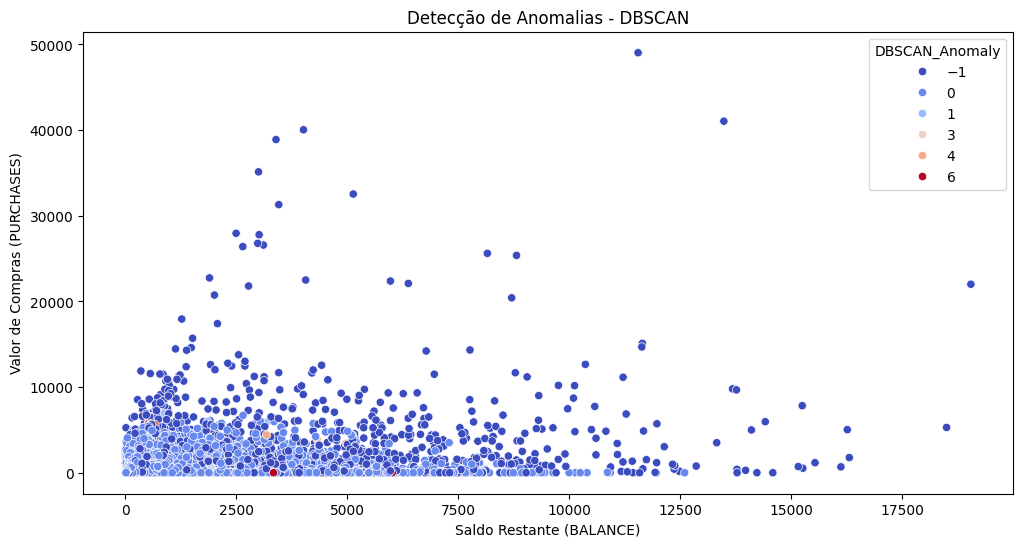

In [ ]:
# Visualizar os resultados do DBSCAN
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df["BALANCE"], y=df["PURCHASES"], hue=df["DBSCAN_Anomaly"], palette="coolwarm")
plt.title("Detecção de Anomalias - DBSCAN")
plt.xlabel("Saldo Restante (BALANCE)")
plt.ylabel("Valor de Compras (PURCHASES)")
plt.show()

In [ ]:
# Contagem de anomalias detectadas
print("Isolation Forest:")
print(df["IsolationForest_Anomaly"].value_counts())

print("\nDBSCAN:")
print(df["DBSCAN_Anomaly"].value_counts())

Isolation Forest:
IsolationForest_Anomaly
 1    8204
-1     432
Name: count, dtype: int64

DBSCAN:
DBSCAN_Anomaly
 0    7311
-1    1297
 6       7
 1       5
 5       5
 3       4
 4       4
 2       3
Name: count, dtype: int64


# Conclusão

Aplicamos duas técnicas de detecção de anomalias, Isolation Forest e DBSCAN, para identificar transações financeiras que se desviam do comportamento típico dos usuários. Utilizamos o saldo restante na conta (BALANCE) e o valor das compras realizadas (PURCHASES) como principais variáveis de análise.

Os resultados mostraram que:
- O **Isolation Forest** identificou **432** anomalias em um total de **8636** transações, classificando-as como outliers (-1), enquanto **8204** transações foram consideradas normais.
- O **DBSCAN** detectou **1297** transações como anômalas (-1), além de pequenos clusters que indicam possíveis padrões distintos de comportamento.

A análise gráfica revelou que as anomalias identificadas pelo Isolation Forest estão distribuídas em diversas regiões do gráfico, principalmente em transações de baixo valor de saldo e compras elevadas. Já o DBSCAN detectou um maior número de anomalias e pequenos grupos de comportamento, demonstrando maior sensibilidade a padrões específicos.

Os resultados indicam que o Isolation Forest é mais conservador na identificação de outliers, enquanto o DBSCAN detecta uma quantidade maior de anomalias e pequenos agrupamentos de padrões distintos. Dependendo do objetivo da análise, cada método pode ser utilizado para diferentes abordagens na detecção de fraudes ou identificação de comportamentos atípicos.

